# Configuration

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt
import random

In [2]:
TICKER = "TSLA"

# Create DataFrame with TICKER

In [3]:
tesla = pd.read_csv(f"../data/features/{TICKER}_features.csv")
print(f"Size of {TICKER} dataset: {tesla.shape}")
tesla.tail()

Size of TSLA dataset: (2139, 135)


,date,open,high,low,close,volume,symbol,log_return,next_day_return,return_lag_1,...,volume_ratio_10_scaled,avg_volume_20_scaled,volume_ratio_20_scaled,vwap_5_scaled,price_to_vwap_scaled,obv_scaled,obv_ema_scaled,daily_range_scaled,close_to_high_scaled,close_to_low_scaled
2134,2025-09-10,350.549988,356.329987,346.070007,347.790009,72121700,TSLA,0.002361,0.058683,0.001644,...,0.115680,-0.659673,0.128312,0.732163,-0.006914,0.489594,0.482450,-0.368822,0.386864,-0.570174
2135,2025-09-11,350.170013,368.989990,347.600006,368.809998,103756000,TSLA,0.058683,0.070981,0.002361,...,1.183327,-0.625163,1.188232,0.761792,0.871030,0.497363,0.485420,0.868640,-0.683293,1.890938
2136,2025-09-12,370.940002,396.690002,370.239990,395.940002,168156400,TSLA,0.070981,0.034992,0.058683,...,2.908975,-0.535657,3.126140,0.830866,1.504557,0.509954,0.490135,1.252966,-0.619351,2.259615
2137,2025-09-15,423.130005,425.700012,402.429993,410.040009,163823700,TSLA,0.034992,0.027850,0.070981,...,2.280659,-0.449659,2.691750,0.896710,1.394234,0.522220,0.496220,0.724579,0.971198,0.041942
2138,2025-09-16,414.500000,423.250000,411.429993,421.619995,104285700,TSLA,0.027850,0.027850,0.034992,...,0.289092,-0.404184,0.717738,0.939174,1.464899,0.530029,0.502617,-0.404446,-0.529991,0.299131


# Visualize Time Series Split

In [4]:
'''
Generates training and testing indices on each time-series-split data

Args:
    data: dataset (or feature matrix) of a stock to split.
    n_splits: Number of folds.
    test_size: Size of each test set.
    gap: Number of samples to exclude between train and test (must be equal to test_size).

Returns:
    List of dicts with keys: (1) "fold": fold number, 0-based (2) "train_idx": training indices (3) "test_idx": testing indices
'''
def createTimeSeriesSplit(data, n_splits = 5, test_size = 90, gap = 50):
    tss = TimeSeriesSplit(n_splits = n_splits, test_size = test_size, gap = gap)

    folds = [] 
    for k, (train_idx, test_idx) in enumerate(tss.split(data)): #enum to add k folds 
        folds.append({
            "fold": k,
            "train_idx": train_idx,  
            "test_idx": test_idx,
        })
    return folds
# create time series split
folds = createTimeSeriesSplit(data=tesla)

In [5]:
def previewFold(folds: list):
    for k in folds:
        print("fold:", k["fold"], "\ntrain_idx", k["train_idx"][:20], "...", k["train_idx"][-20:], 
                        "\ntest_idex", k["test_idx"][:20], "...", k["test_idx"][-15:])
previewFold(folds)

fold: 0 
train_idx [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19] ... [1619 1620 1621 1622 1623 1624 1625 1626 1627 1628 1629 1630 1631 1632
 1633 1634 1635 1636 1637 1638] 
test_idex [1689 1690 1691 1692 1693 1694 1695 1696 1697 1698 1699 1700 1701 1702
 1703 1704 1705 1706 1707 1708] ... [1764 1765 1766 1767 1768 1769 1770 1771 1772 1773 1774 1775 1776 1777
 1778]
fold: 1 
train_idx [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19] ... [1709 1710 1711 1712 1713 1714 1715 1716 1717 1718 1719 1720 1721 1722
 1723 1724 1725 1726 1727 1728] 
test_idex [1779 1780 1781 1782 1783 1784 1785 1786 1787 1788 1789 1790 1791 1792
 1793 1794 1795 1796 1797 1798] ... [1854 1855 1856 1857 1858 1859 1860 1861 1862 1863 1864 1865 1866 1867
 1868]
fold: 2 
train_idx [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19] ... [1799 1800 1801 1802 1803 1804 1805 1806 1807 1808 1809 1810 1811 1812
 1813 1814 1815 1816 1817 1818] 
test_idex [1869 1870 1871 1872 1873 1874 18

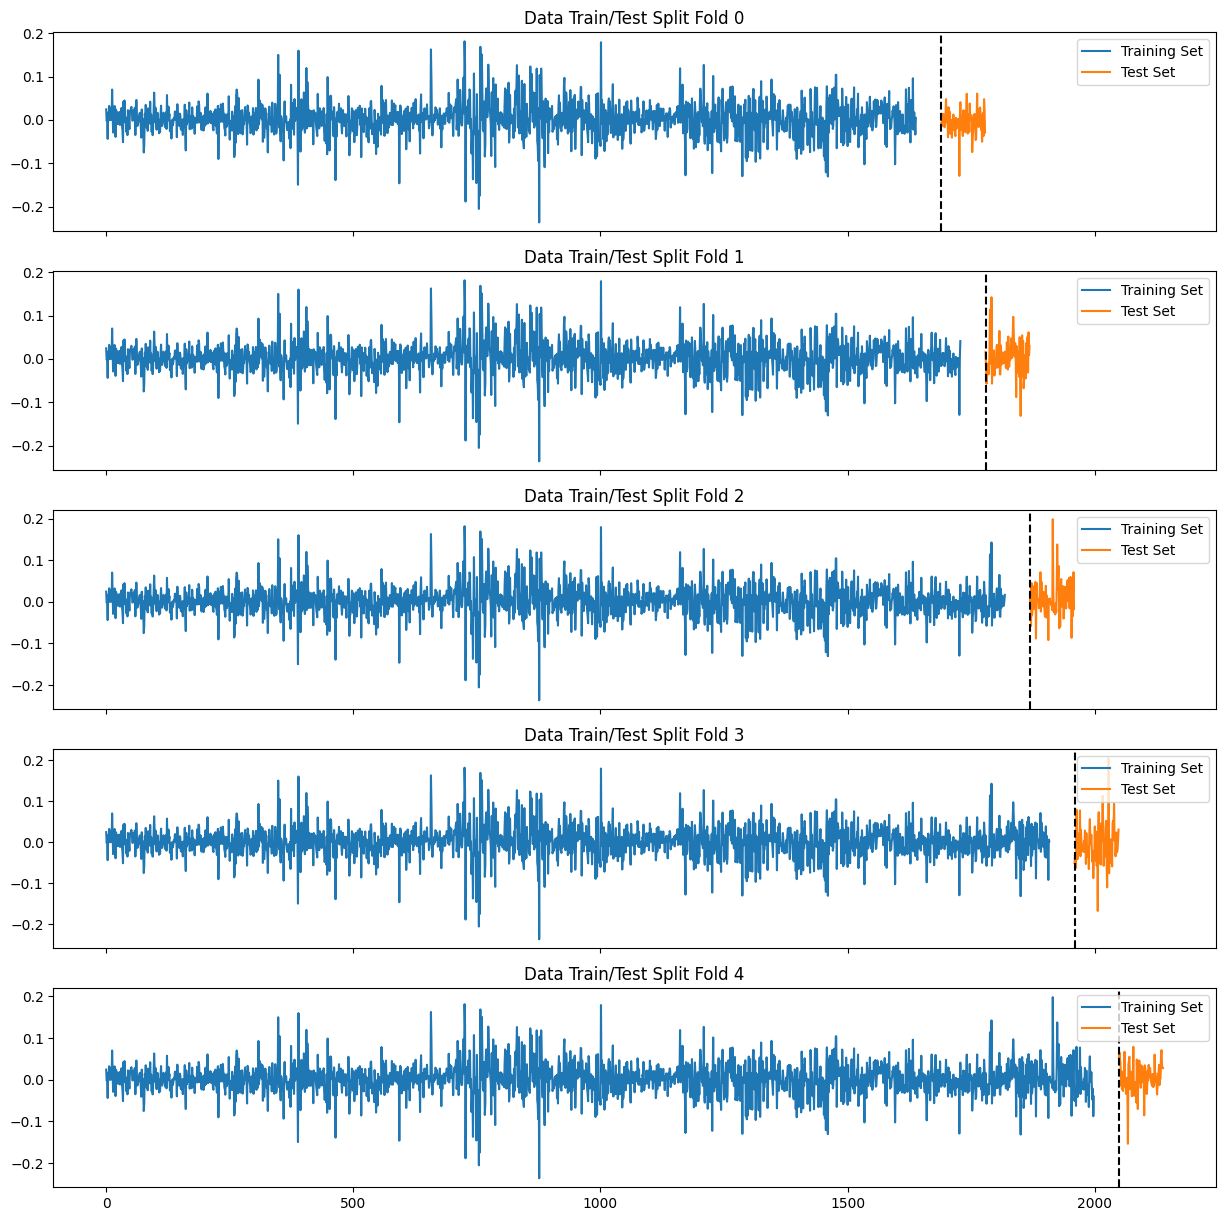

In [6]:
# Visualize each fold in TimeSeriesSplit CV
fig, axs = plt.subplots(5, 1, figsize=(15, 15), sharex=True)

for fold in folds: 
    k = fold["fold"]
    train_idx = fold["train_idx"]
    test_idx  = fold["test_idx"]

    train = tesla.iloc[train_idx]
    test  = tesla.iloc[test_idx]

    ax = axs[k]
    train['next_day_return'].plot(ax=ax,label="Training Set", title=f"Data Train/Test Split Fold {k}")
    test['next_day_return'].plot(ax=ax, label="Test Set")
    ax.legend(loc="upper right")
    ax.axvline(test.index.min(), color="black", ls="--")

plt.show()